In [50]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

from PIL import Image
import torch
from torch.utils.data import Dataset

import albumentations as A
from albumentations.pytorch import ToTensorV2


# -----------------------------
# Utility: label mapping
# -----------------------------
HAM10000_LABELS = [
    "akiec",  # Actinic keratoses
    "bcc",    # Basal cell carcinoma
    "bkl",    # Benign keratosis-like lesions
    "df",     # Dermatofibroma
    "mel",    # Melanoma
    "nv",     # Melanocytic nevi
    "vasc"    # Vascular lesions
]
LABEL2IDX = {c: i for i, c in enumerate(HAM10000_LABELS)}


# -----------------------------
# Default transforms
# -----------------------------
def get_train_transforms(img_size=224):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.02, scale_limit=0.10, rotate_limit=20, p=0.5),
        A.RandomBrightnessContrast(p=0.4),
        A.Normalize(),   # uses ImageNet-like scaling (0-1 then z-score). good for pretrained backbones
        ToTensorV2()
    ])


def get_valid_transforms(img_size=224):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(),
        ToTensorV2()
    ])


# -----------------------------
# Multi-task dataset
# returns: image_tensor, class_id, mask_tensor
# -----------------------------
class Ham10000MultiTaskDataset(Dataset):
    def __init__(
        self,
        root_dir: str,
        split_df: pd.DataFrame,
        transforms=None,
        image_folder="images",
        mask_folder="masks",
        image_ext=".jpg",
        mask_suffix="_segmentation.png",
        diagnosis_col="dx",         # HAM10000 metadata uses 'dx'
        image_id_col="image_id",    # HAM10000 metadata uses 'image_id'
        strict=True
    ):
        """
        root_dir: dataset root path (contains images/, masks/, metadata.csv)
        split_df: dataframe containing at least [image_id_col, diagnosis_col]
        transforms: albumentations transforms with both image+mask support
        strict: if True, raise error when an image/mask is missing
        """
        self.root_dir = Path(root_dir)
        self.images_dir = self.root_dir / image_folder
        self.masks_dir = self.root_dir / mask_folder

        self.df = split_df.reset_index(drop=True).copy()
        self.transforms = transforms
        self.image_ext = image_ext
        self.mask_suffix = mask_suffix
        self.diagnosis_col = diagnosis_col
        self.image_id_col = image_id_col
        self.strict = strict

        # Basic column checks
        if self.image_id_col not in self.df.columns:
            raise ValueError(f"'{self.image_id_col}' column not found in split_df")
        if self.diagnosis_col not in self.df.columns:
            raise ValueError(f"'{self.diagnosis_col}' column not found in split_df")

        # Precompute file paths + class ids
        self.samples = []
        missing = []
        for _, row in self.df.iterrows():
            image_id = str(row[self.image_id_col])
            dx = str(row[self.diagnosis_col])

            if dx not in LABEL2IDX:
                missing.append((image_id, f"Unknown label '{dx}'"))
                continue

            img_path = self.images_dir / f"{image_id}{self.image_ext}"
            mask_path = self.masks_dir / f"{image_id}{self.mask_suffix}"

            if not img_path.exists():
                missing.append((image_id, f"Missing image: {img_path}"))
                continue
            if not mask_path.exists():
                missing.append((image_id, f"Missing mask: {mask_path}"))
                continue

            self.samples.append((image_id, img_path, mask_path, LABEL2IDX[dx]))

        if missing and self.strict:
            msg = "\n".join([f"{i}: {err}" for i, err in missing[:20]])
            raise FileNotFoundError(
                f"Found {len(missing)} issues while building dataset. First 20:\n{msg}"
            )

        if len(self.samples) == 0:
            raise RuntimeError("No valid samples found. Check paths/columns/filenames.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_id, img_path, mask_path, class_id = self.samples[idx]

        # Read image (RGB)
        image = np.array(Image.open(img_path).convert("RGB"))

        # Read mask (grayscale), convert to binary 0/1
        mask = np.array(Image.open(mask_path).convert("L"))
        mask = (mask > 0).astype(np.uint8)  # binary

        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented["image"]  # Tensor CxHxW
            mask = augmented["mask"]    # Tensor HxW (uint8 or float depending)
        else:
            # fallback: convert to torch tensors
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()

        # Ensure mask is float for BCE/Dice (shape: 1xHxW)
        if isinstance(mask, torch.Tensor):
            mask = mask.unsqueeze(0).float()

        label = torch.tensor(class_id).long()
        return image, label, mask, image_id


In [8]:
# import albumentations as A
# print(A.__version__)


In [9]:
# import sys
# print(sys.executable)


In [ ]:
# import os
# print(os.getcwd())


/Users/afnanbinislamnahin/Library/CloudStorage/OneDrive-AmericanInternationalUniversity-Bangladesh/Research Methodology/skin cancer/dataset1


In [51]:
from sklearn.model_selection import train_test_split

meta_path = "HAM10000_metadata.csv"
df = pd.read_csv(meta_path)

# Keep only rows that have files (optional quick filter)
# df = df[df["image_id"].notna()]

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["dx"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["dx"]
)

print(len(train_df), len(val_df), len(test_df))


7010 1502 1503


In [52]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("HAM10000_metadata.csv")

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["dx"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["dx"], random_state=42)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))


Train: 7010
Val: 1502
Test: 1503


In [53]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# (Optional) verify you are in the right folder
print("Current working directory:", os.getcwd())
print("Files here:", os.listdir("."))

# Read metadata (same folder)
df = pd.read_csv("HAM10000_metadata.csv")

# Split (stratified by diagnosis)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["dx"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["dx"]
)

# Create datasets (root_dir is current folder ".")
train_ds = Ham10000MultiTaskDataset(
    root_dir=".",
    split_df=train_df,
    transforms=get_train_transforms(img_size=224),
    strict=False
)

val_ds = Ham10000MultiTaskDataset(
    root_dir=".",
    split_df=val_df,
    transforms=get_valid_transforms(img_size=224),
    strict=False
)

# Mac-safe DataLoaders (avoid hanging)
train_loader = DataLoader(
    train_ds,
    batch_size=8,        # start small on Mac
    shuffle=True,
    num_workers=0,       # IMPORTANT for Mac
    pin_memory=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# Sanity check
images, labels, masks, ids = next(iter(train_loader))
print("images:", images.shape, "labels:", labels.shape, "masks:", masks.shape)
print("sample ids:", ids[:3])


Current working directory: /Users/afnanbinislamnahin/Library/CloudStorage/OneDrive-AmericanInternationalUniversity-Bangladesh/Research Methodology/skin cancer/dataset1
Files here: ['.DS_Store', 'images', 'best_model_swin_unet_30epoch.pth', 'best_effb0_unet_f1.pth', 'best_model_f1.pth', 'skin_cancer.ipynb', 'HAM10000_metadata.csv', 'masks', 'pr_curve.png']


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


images: torch.Size([8, 3, 224, 224]) labels: torch.Size([8]) masks: torch.Size([8, 1, 224, 224])
sample ids: ('ISIC_0033725', 'ISIC_0024777', 'ISIC_0032314')


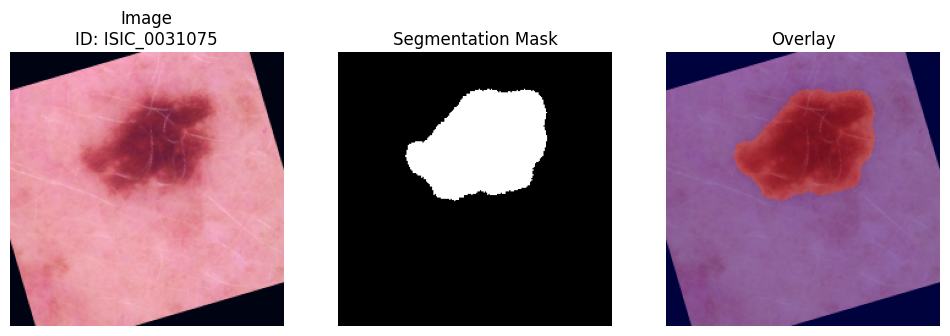

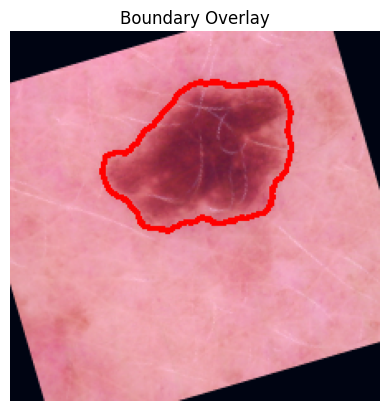

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch
images, labels, masks, ids = next(iter(train_loader))

# Pick one sample from batch
idx = 0

image = images[idx].permute(1, 2, 0).cpu().numpy()
mask = masks[idx].squeeze().cpu().numpy()

# Normalize image back to 0-1 for display
image = (image - image.min()) / (image.max() - image.min())

plt.figure(figsize=(12,5))

# Original Image
plt.subplot(1,3,1)
plt.imshow(image)
plt.title(f"Image\nID: {ids[idx]}")
plt.axis("off")

# Mask
plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Segmentation Mask")
plt.axis("off")

# Overlay
plt.subplot(1,3,3)
plt.imshow(image)
plt.imshow(mask, cmap="jet", alpha=0.4)
plt.title("Overlay")
plt.axis("off")

plt.show()

import cv2

contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
overlay = image.copy()
cv2.drawContours(overlay, contours, -1, (1,0,0), 2)

plt.imshow(overlay)
plt.title("Boundary Overlay")
plt.axis("off")
plt.show()


In [55]:
#part--------5
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm


# ---- helper: timm output sometimes NHWC, convert to NCHW ----
def to_nchw(x):
    # If output is [B,H,W,C] (NHWC) convert to [B,C,H,W]
    if x.ndim == 4 and x.shape[-1] in (96, 192, 384, 768, 1024):
        return x.permute(0, 3, 1, 2).contiguous()
    return x


# ---- small conv blocks ----
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv1 = ConvBNReLU(in_ch + skip_ch, out_ch)
        self.conv2 = ConvBNReLU(out_ch, out_ch)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        return x


# ---- Main multi-task model ----
class SwinUNetMultiTask(nn.Module):
    """
    Encoder: Swin Transformer (ViT family) from timm (features_only=True)
    Decoder: U-Net style
    Outputs:
      - cls_logits: (B, num_classes)
      - seg_logits: (B, 1, H, W)  -> logits (use sigmoid later)
    """
    def __init__(self, encoder_name="swin_tiny_patch4_window7_224", num_classes=7):
        super().__init__()

        # multi-scale features
        self.encoder = timm.create_model(
            encoder_name,
            pretrained=True,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        chs = self.encoder.feature_info.channels()  # typically [96,192,384,768]

        # bridge
        self.bridge = nn.Sequential(
            ConvBNReLU(chs[-1], 512),
            ConvBNReLU(512, 512),
        )

        # decoder
        self.up3 = UpBlock(in_ch=512, skip_ch=chs[2], out_ch=256)
        self.up2 = UpBlock(in_ch=256, skip_ch=chs[1], out_ch=128)
        self.up1 = UpBlock(in_ch=128, skip_ch=chs[0], out_ch=64)

        # final up to 224x224 (swin stage0 usually 56x56 -> x4)
        self.final_up = nn.Sequential(
            nn.Upsample(scale_factor=4, mode="bilinear", align_corners=False),
            ConvBNReLU(64, 32),
            nn.Conv2d(32, 1, kernel_size=1)  # seg logits
        )

        # classification head (from bridge 512)
        self.cls_pool = nn.AdaptiveAvgPool2d(1)
        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        feats = self.encoder(x)            # list of features
        feats = [to_nchw(f) for f in feats]  # ensure NCHW
        f0, f1, f2, f3 = feats

        x_bridge = self.bridge(f3)

        # classification
        cls_logits = self.cls_head(self.cls_pool(x_bridge))

        # segmentation
        x = self.up3(x_bridge, f2)
        x = self.up2(x, f1)
        x = self.up1(x, f0)
        seg_logits = self.final_up(x)

        return cls_logits, seg_logits



In [56]:
#part--5
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = SwinUNetMultiTask(num_classes=7).to(device)

images, labels, masks, ids = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    cls_logits, seg_logits = model(images)

print("cls_logits:", cls_logits.shape)  # expected [B,7]
print("seg_logits:", seg_logits.shape)  # expected [B,1,224,224]



cls_logits: torch.Size([8, 7])
seg_logits: torch.Size([8, 1, 224, 224])


In [57]:
#Part 6 = Loss Functions + Optimizer + 1-step training sanity
#6.1 Dice Loss
import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        """
        logits:  (B,1,H,W)
        targets: (B,1,H,W) in {0,1}
        """
        probs = torch.sigmoid(logits)
        num = 2 * (probs * targets).sum(dim=(2,3))
        den = (probs + targets).sum(dim=(2,3)) + self.eps
        dice = 1 - (num / den)
        return dice.mean()


In [58]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = SwinUNetMultiTask(num_classes=7).to(device)
print("Model created on:", device)


Model created on: mps


In [59]:
model.load_state_dict(torch.load("best_model_f1.pth", map_location=device))
model.eval()

print("✅ Loaded best_model_f1.pth successfully")


✅ Loaded best_model_f1.pth successfully


In [60]:
#part 6
#6.2 Loss objects + Multi-task loss function

bce_loss  = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()
ce_loss   = nn.CrossEntropyLoss()  # (later we will replace with weighted CE)

def multitask_loss(cls_logits, seg_logits, labels, masks, alpha=0.5, beta=0.5):
    """
    cls_logits: (B,7)
    seg_logits: (B,1,H,W)
    labels:     (B,)
    masks:      (B,1,H,W)
    """
    L_cls = ce_loss(cls_logits, labels)
    L_seg = 0.5 * bce_loss(seg_logits, masks) + 0.5 * dice_loss(seg_logits, masks)
    total = alpha * L_cls + beta * L_seg
    return total, L_cls.detach(), L_seg.detach()


In [61]:
#part--6
#6.3 Optimizer + 1 training step sanity check
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)


In [64]:
#part--6
#6.4 One-step training sanity (Forward + Backward)
model.train()

images, labels, masks, ids = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)
masks  = masks.to(device)

cls_logits, seg_logits = model(images)

loss, L_cls, L_seg = multitask_loss(cls_logits, seg_logits, labels, masks, alpha=0.5, beta=0.5)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("OK ✅ one training step done")
print("Total loss:", loss.detach().item(), "Cls:", L_cls.item(), "Seg:", L_seg.item())
print("cls_logits:", cls_logits.shape, "seg_logits:", seg_logits.shape)


OK ✅ one training step done
Total loss: 0.964162290096283 Cls: 1.8368514776229858 Seg: 0.0914730653166771
cls_logits: torch.Size([8, 7]) seg_logits: torch.Size([8, 1, 224, 224])


In [65]:
#6.5.1 Weighted CrossEntropyLoss
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler

# class counts from train_df
class_counts = train_df["dx"].value_counts()

# weights: inverse frequency
w_ce = np.array([1.0 / class_counts.get(c, 1) for c in HAM10000_LABELS], dtype=np.float32)
w_ce = w_ce / w_ce.sum() * len(w_ce)  # normalize

ce_loss = nn.CrossEntropyLoss(weight=torch.tensor(w_ce).to(device))

print("✅ Weighted CE weights:")
for i, c in enumerate(HAM10000_LABELS):
    print(f"{c:5s}: {w_ce[i]:.4f}")


✅ Weighted CE weights:
akiec: 0.9438
bcc  : 0.6004
bkl  : 0.2810
df   : 2.6682
mel  : 0.2774
nv   : 0.0461
vasc : 2.1831


In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

df = pd.read_csv("HAM10000_metadata.csv")

class_distribution = df["dx"].value_counts().reindex(
    ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
)

print(class_distribution)
print("Total:", class_distribution.sum())

dx
akiec     327
bcc       514
bkl      1099
df        115
mel      1113
nv       6705
vasc      142
Name: count, dtype: int64
Total: 10015


In [66]:
#6.5.2 Balanced Sampler + rebuild train_loader
# sample weights per row
sample_weights = train_df["dx"].map(lambda x: 1.0 / class_counts[x]).values
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

# rebuild train_loader (IMPORTANT: do not use shuffle with sampler)
train_loader = DataLoader(
    train_ds,
    batch_size=8,
    sampler=sampler,
    num_workers=0,
    pin_memory=False
)

print("✅ train_loader rebuilt with WeightedRandomSampler")


✅ train_loader rebuilt with WeightedRandomSampler


In [67]:
#7.1 Validation: loss + classification metrics (epoch-level)
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def validate_one_epoch(model, loader, device, num_classes=7, alpha=0.5, beta=0.5):
    model.eval()

    total_loss = 0.0
    n_batches = 0

    all_probs = []
    all_y = []

    for images, labels, masks, _ids in loader:
        images = images.to(device)
        labels = labels.to(device)
        masks  = masks.to(device)

        cls_logits, seg_logits = model(images)

        loss, _, _ = multitask_loss(cls_logits, seg_logits, labels, masks, alpha=alpha, beta=beta)
        total_loss += loss.detach().item()
        n_batches += 1

        probs = torch.softmax(cls_logits, dim=1)
        all_probs.append(probs.detach().cpu().numpy())
        all_y.append(labels.detach().cpu().numpy())

    val_loss = total_loss / max(n_batches, 1)

    y_prob = np.concatenate(all_probs, axis=0)
    y_true = np.concatenate(all_y, axis=0)

    # Accuracy
    y_pred = y_prob.argmax(axis=1)
    acc = float((y_pred == y_true).mean())

    # Macro-F1 (manual)
    f1s = []
    for c in range(num_classes):
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        denom = (2*tp + fp + fn)
        f1 = (2*tp/denom) if denom > 0 else 0.0
        f1s.append(f1)
    macro_f1 = float(np.mean(f1s))

    # ROC-AUC OvR (macro)
    y_onehot = np.eye(num_classes)[y_true]
    try:
        auc = float(roc_auc_score(y_onehot, y_prob, average="macro", multi_class="ovr"))
    except Exception:
        auc = None

    return val_loss, acc, macro_f1, auc


In [68]:
#7.2 Train one epoch (already have, but use detach properly)
def train_one_epoch(model, loader, optimizer, device, alpha=0.5, beta=0.5):
    model.train()
    total_loss = 0.0

    for images, labels, masks, _ids in loader:
        images = images.to(device)
        labels = labels.to(device)
        masks  = masks.to(device)

        cls_logits, seg_logits = model(images)
        loss, _, _ = multitask_loss(cls_logits, seg_logits, labels, masks, alpha=alpha, beta=beta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.detach().item()

    return total_loss / max(len(loader), 1)


Epoch 01 | TrainLoss=0.1457 | ValLoss=0.4387 | Acc=0.5992 | MacroF1=0.5978 | AUC=0.9365585796810265
✅ Saved best_model_f1.pth (best Macro-F1)
Epoch 02 | TrainLoss=0.1463 | ValLoss=0.5679 | Acc=0.5013 | MacroF1=0.5231 | AUC=0.9197470126528989
Epoch 03 | TrainLoss=0.1320 | ValLoss=0.4230 | Acc=0.6438 | MacroF1=0.6814 | AUC=0.9567172035143213
✅ Saved best_model_f1.pth (best Macro-F1)
Epoch 04 | TrainLoss=0.1132 | ValLoss=0.6906 | Acc=0.3895 | MacroF1=0.4752 | AUC=0.9015140159232135
Epoch 05 | TrainLoss=0.1152 | ValLoss=0.6479 | Acc=0.5652 | MacroF1=0.5634 | AUC=0.9338964906797579
Epoch 06 | TrainLoss=0.1204 | ValLoss=0.4191 | Acc=0.6704 | MacroF1=0.6726 | AUC=0.9560898589315919
Epoch 07 | TrainLoss=0.1111 | ValLoss=0.4894 | Acc=0.6558 | MacroF1=0.6325 | AUC=0.9518280931091461
Epoch 08 | TrainLoss=0.1366 | ValLoss=0.5894 | Acc=0.4654 | MacroF1=0.5130 | AUC=0.9034580496880535
Epoch 09 | TrainLoss=0.1050 | ValLoss=0.4069 | Acc=0.6585 | MacroF1=0.6820 | AUC=0.9606254424536899
✅ Saved best_mod

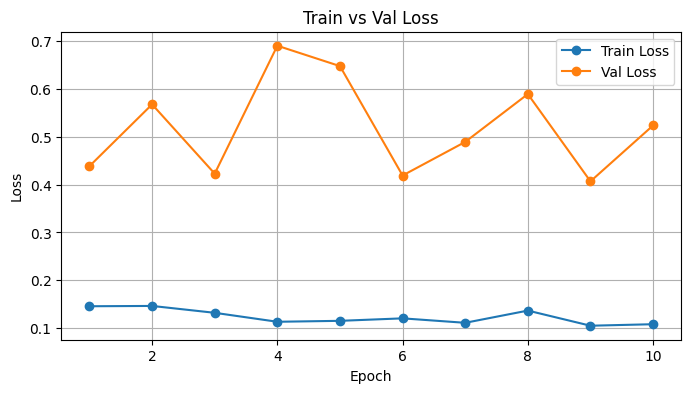

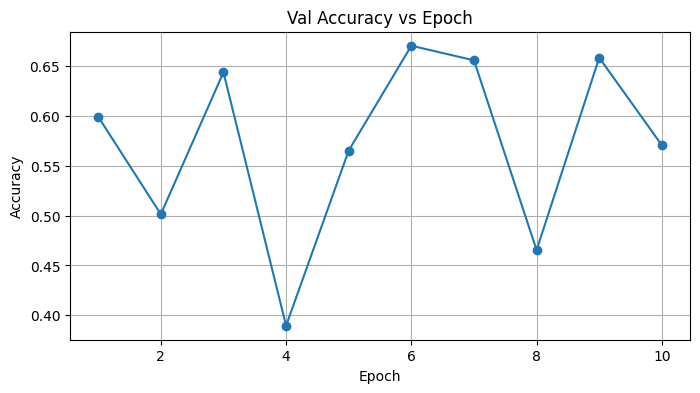

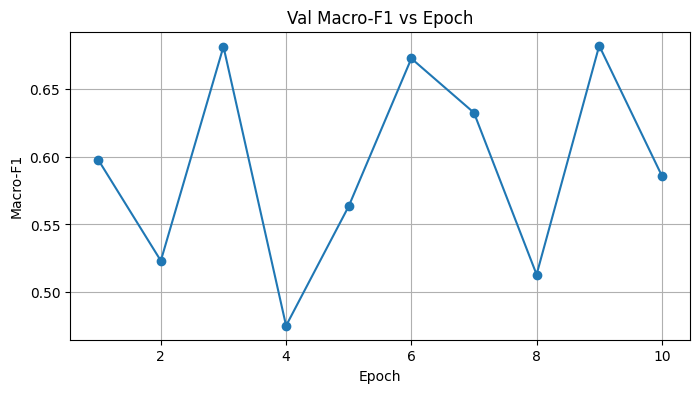

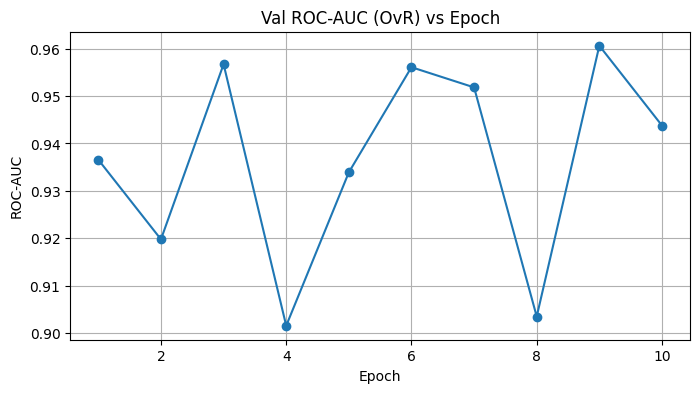

✅ Training complete. Best Macro-F1: 0.6820226252049609


In [25]:
#7.3 Full training loop + save best model + plot graphs
import matplotlib.pyplot as plt

EPOCHS = 10
best_f1 = -1.0

train_losses = []
val_losses   = []
val_accs     = []
val_f1s      = []
val_aucs     = []

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, device)
    v_loss, v_acc, v_f1, v_auc = validate_one_epoch(model, val_loader, device)

    train_losses.append(tr_loss)
    val_losses.append(v_loss)
    val_accs.append(v_acc)
    val_f1s.append(v_f1)
    val_aucs.append(v_auc)

    print(f"Epoch {epoch:02d} | TrainLoss={tr_loss:.4f} | ValLoss={v_loss:.4f} | Acc={v_acc:.4f} | MacroF1={v_f1:.4f} | AUC={v_auc if v_auc is not None else 'NA'}")

    # save best checkpoint by Macro-F1
    if v_f1 > best_f1:
        best_f1 = v_f1
        torch.save(model.state_dict(), "best_model_f1.pth")
        print("✅ Saved best_model_f1.pth (best Macro-F1)")

# ---- Plot Train vs Val Loss ----
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(8,4))
plt.plot(epochs, train_losses, marker="o", label="Train Loss")
plt.plot(epochs, val_losses, marker="o", label="Val Loss")
plt.title("Train vs Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(True); plt.legend()
plt.show()

# ---- Plot Accuracy ----
plt.figure(figsize=(8,4))
plt.plot(epochs, val_accs, marker="o")
plt.title("Val Accuracy vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# ---- Plot Macro-F1 ----
plt.figure(figsize=(8,4))
plt.plot(epochs, val_f1s, marker="o")
plt.title("Val Macro-F1 vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Macro-F1")
plt.grid(True)
plt.show()

# ---- Plot ROC-AUC ----
plt.figure(figsize=(8,4))
auc_vals = [np.nan if v is None else v for v in val_aucs]
plt.plot(epochs, auc_vals, marker="o")
plt.title("Val ROC-AUC (OvR) vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("ROC-AUC")
plt.grid(True)
plt.show()

print("✅ Training complete. Best Macro-F1:", best_f1)


In [69]:
# 8.1 — Load best checkpoint
model.load_state_dict(torch.load("best_model_f1.pth", map_location=device))
model.eval()
print("✅ Loaded best_model_f1.pth")


✅ Loaded best_model_f1.pth


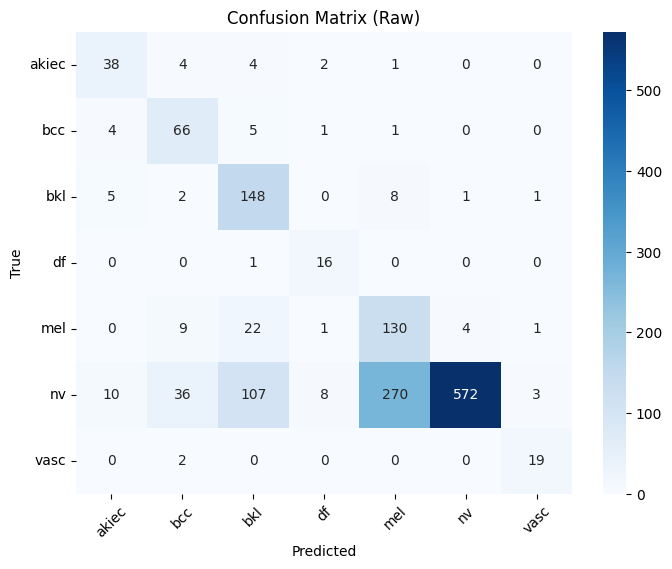

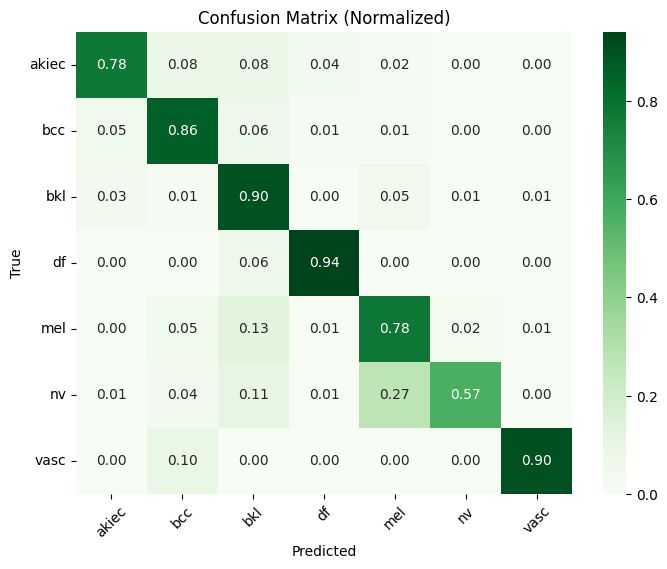

VAL Confusion Matrix:
 [[ 38   4   4   2   1   0   0]
 [  4  66   5   1   1   0   0]
 [  5   2 148   0   8   1   1]
 [  0   0   1  16   0   0   0]
 [  0   9  22   1 130   4   1]
 [ 10  36 107   8 270 572   3]
 [  0   2   0   0   0   0  19]]


In [70]:
# ✅ PART 8.2 — Confusion Matrix (VAL বা TEST)
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import torch

@torch.no_grad()
def plot_confusion_matrix(model, loader, device, class_names):
    model.eval()
    y_true=[]; y_pred=[]
    for images, labels, masks, _ in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits, _ = model(images)
        preds = logits.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Raw)")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(rotation=45); plt.yticks(rotation=0)
    plt.show()

    cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    plt.figure(figsize=(8,6))
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Greens",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Normalized)")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(rotation=45); plt.yticks(rotation=0)
    plt.show()

    return cm

cm_val = plot_confusion_matrix(model, val_loader, device, HAM10000_LABELS)
print("VAL Confusion Matrix:\n", cm_val)


In [8]:
print(test_df.head())

NameError: name 'test_df' is not defined

In [71]:
#✅ STEP 1 — test_ds বানান
test_ds = Ham10000MultiTaskDataset(
    root_dir=".",
    split_df=test_df,
    transforms=get_valid_transforms(img_size=224),
    strict=False
)


In [72]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_ds,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print("✅ test_loader ready")


✅ test_loader ready


In [73]:
#✅ PART 8.3 — Dice / IoU Table (VAL + TEST)
@torch.no_grad()
def seg_metrics_epoch(model, loader, device, thr=0.5, eps=1e-6):
    model.eval()
    dices=[]; ious=[]
    for images, labels, masks, _ in loader:
        images = images.to(device)
        masks  = masks.to(device)

        _, seg_logits = model(images)
        probs = torch.sigmoid(seg_logits)
        preds = (probs > thr).float()

        inter = (preds*masks).sum(dim=(2,3))
        dice  = (2*inter + eps) / ((preds+masks).sum(dim=(2,3)) + eps)
        iou   = (inter + eps) / ((preds+masks - preds*masks).sum(dim=(2,3)) + eps)

        dices.append(dice.mean().item())
        ious.append(iou.mean().item())

    return float(np.mean(dices)), float(np.mean(ious))

val_dice, val_iou = seg_metrics_epoch(model, val_loader, device)
test_dice, test_iou = seg_metrics_epoch(model, test_loader, device)

print("\n📌 Segmentation Metrics Table")
print("-----------------------------------")
print(f"VAL  Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")
print(f"TEST Dice: {test_dice:.4f} | IoU: {test_iou:.4f}")
print("-----------------------------------")



📌 Segmentation Metrics Table
-----------------------------------
VAL  Dice: 0.9439 | IoU: 0.8991
TEST Dice: 0.9398 | IoU: 0.8936
-----------------------------------


In [75]:
#✅ PART 8.4 — Real-time benchmark + Model size
import time

@torch.no_grad()
def measure_latency_fps(model, device, img_size=224, batch_size=1, warmup=10, iters=50):
    model.eval()
    x = torch.randn(batch_size, 3, img_size, img_size).to(device)

    for _ in range(warmup):
        _ = model(x)

    t0 = time.perf_counter()
    for _ in range(iters):
        _ = model(x)
    t1 = time.perf_counter()

    avg = (t1-t0)/iters
    return {"latency_ms": avg*1000.0, "fps": batch_size/avg}

def model_size_mb(model):
    param_bytes = sum(p.numel()*p.element_size() for p in model.parameters())
    buffer_bytes = sum(b.numel()*b.element_size() for b in model.buffers())
    total_mb = (param_bytes+buffer_bytes)/(1024**2)
    params_m = sum(p.numel() for p in model.parameters())/1e6
    return {"model_size_mb": total_mb, "params_million": params_m}

print("REAL-TIME:", measure_latency_fps(model, device, img_size=224, batch_size=1))
print("MODEL:", model_size_mb(model))


REAL-TIME: {'latency_ms': 13.76811915950384, 'fps': 72.63156197407845}
MODEL: {'model_size_mb': 142.43179321289062, 'params_million': 37.055202}


In [76]:
print("images:", images.shape)
print("labels:", labels.shape)
print("masks :", masks.shape)


images: torch.Size([8, 3, 224, 224])
labels: torch.Size([8])
masks : torch.Size([8, 1, 224, 224])


In [ ]:
#Part A — Baseline model: ResNet18 + U-Net + Classification Head**


In [77]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

In [78]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv1 = ConvBNReLU(in_ch + skip_ch, out_ch)
        self.conv2 = ConvBNReLU(out_ch, out_ch)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        return x

In [79]:
class ResNet18UNetMultiTask(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()

        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)

        # ----- Encoder -----
        self.initial = nn.Sequential(
            backbone.conv1,   # 64, /2
            backbone.bn1,
            backbone.relu
        )  # output: 64 x 112 x 112

        self.maxpool = backbone.maxpool   # /2 -> 56x56

        self.encoder1 = backbone.layer1   # 64, 56x56
        self.encoder2 = backbone.layer2   # 128, 28x28
        self.encoder3 = backbone.layer3   # 256, 14x14
        self.encoder4 = backbone.layer4   # 512, 7x7

        # ----- Classification head -----
        self.cls_pool = nn.AdaptiveAvgPool2d(1)
        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

        # ----- Decoder -----
        self.bridge = nn.Sequential(
            ConvBNReLU(512, 512),
            ConvBNReLU(512, 512)
        )

        self.up3 = UpBlock(in_ch=512, skip_ch=256, out_ch=256)
        self.up2 = UpBlock(in_ch=256, skip_ch=128, out_ch=128)
        self.up1 = UpBlock(in_ch=128, skip_ch=64, out_ch=64)
        self.up0 = UpBlock(in_ch=64, skip_ch=64, out_ch=32)

        self.final_up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),  # 112 -> 224
            ConvBNReLU(32, 16),
            nn.Conv2d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        # Encoder
        x0 = self.initial(x)              # [B,64,112,112]
        x1 = self.maxpool(x0)             # [B,64,56,56]
        x1 = self.encoder1(x1)            # [B,64,56,56]
        x2 = self.encoder2(x1)            # [B,128,28,28]
        x3 = self.encoder3(x2)            # [B,256,14,14]
        x4 = self.encoder4(x3)            # [B,512,7,7]

        # Classification
        cls_logits = self.cls_head(self.cls_pool(x4))

        # Segmentation
        b = self.bridge(x4)
        d3 = self.up3(b, x3)              # [B,256,14,14]
        d2 = self.up2(d3, x2)             # [B,128,28,28]
        d1 = self.up1(d2, x1)             # [B,64,56,56]
        d0 = self.up0(d1, x0)             # [B,32,112,112]
        seg_logits = self.final_up(d0)    # [B,1,224,224]

        return cls_logits, seg_logits

In [80]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

baseline_model = ResNet18UNetMultiTask(num_classes=7).to(device)

images, labels, masks, ids = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    cls_logits, seg_logits = baseline_model(images)

print("cls_logits:", cls_logits.shape)
print("seg_logits:", seg_logits.shape)

cls_logits: torch.Size([8, 7])
seg_logits: torch.Size([8, 1, 224, 224])


In [81]:
baseline_optimizer = torch.optim.AdamW(baseline_model.parameters(), lr=1e-4, weight_decay=1e-4)

In [82]:
baseline_model.train()

images, labels, masks, ids = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)
masks = masks.to(device)

cls_logits, seg_logits = baseline_model(images)
loss, L_cls, L_seg = multitask_loss(cls_logits, seg_logits, labels, masks)

baseline_optimizer.zero_grad()
loss.backward()
baseline_optimizer.step()

print("OK ✅ ResNet18 baseline one-step training done")
print("Total loss:", loss.detach().item(), "Cls:", L_cls.item(), "Seg:", L_seg.item())
print("cls_logits:", cls_logits.shape, "seg_logits:", seg_logits.shape)

OK ✅ ResNet18 baseline one-step training done
Total loss: 1.3193395137786865 Cls: 1.8519039154052734 Seg: 0.7867752313613892
cls_logits: torch.Size([8, 7]) seg_logits: torch.Size([8, 1, 224, 224])


In [86]:
EPOCHS = 10
best_f1_baseline = -1.0

train_losses_base = []
val_losses_base   = []#
val_accs_base     = []
val_f1s_base      = []
val_aucs_base     = []

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(baseline_model, train_loader, baseline_optimizer, device)
    v_loss, v_acc, v_f1, v_auc = validate_one_epoch(baseline_model, val_loader, device)

    train_losses_base.append(tr_loss)
    val_losses_base.append(v_loss)
    val_accs_base.append(v_acc)
    val_f1s_base.append(v_f1)
    val_aucs_base.append(v_auc)

    print(f"[Baseline] Epoch {epoch:02d} | TrainLoss={tr_loss:.4f} | ValLoss={v_loss:.4f} | Acc={v_acc:.4f} | MacroF1={v_f1:.4f} | AUC={v_auc if v_auc is not None else 'NA'}")

    if v_f1 > best_f1_baseline:
        best_f1_baseline = v_f1
        torch.save(baseline_model.state_dict(), "best_resnet18_unet_f1.pth")
        print("✅ Saved best_resnet18_unet_f1.pth")

[Baseline] Epoch 01 | TrainLoss=0.5508 | ValLoss=0.9136 | Acc=0.2577 | MacroF1=0.2962 | AUC=0.8822475852679185
✅ Saved best_resnet18_unet_f1.pth
[Baseline] Epoch 02 | TrainLoss=0.3708 | ValLoss=0.7777 | Acc=0.4434 | MacroF1=0.3988 | AUC=0.8814945859406371
✅ Saved best_resnet18_unet_f1.pth
[Baseline] Epoch 03 | TrainLoss=0.3004 | ValLoss=0.5442 | Acc=0.5619 | MacroF1=0.5279 | AUC=0.9355805525867417
✅ Saved best_resnet18_unet_f1.pth
[Baseline] Epoch 04 | TrainLoss=0.2369 | ValLoss=0.5233 | Acc=0.5533 | MacroF1=0.4849 | AUC=0.9351257868332274
[Baseline] Epoch 05 | TrainLoss=0.2288 | ValLoss=0.4944 | Acc=0.5979 | MacroF1=0.5566 | AUC=0.9396526345882682
✅ Saved best_resnet18_unet_f1.pth
[Baseline] Epoch 06 | TrainLoss=0.1850 | ValLoss=0.4531 | Acc=0.6158 | MacroF1=0.5794 | AUC=0.9443693385258554
✅ Saved best_resnet18_unet_f1.pth
[Baseline] Epoch 07 | TrainLoss=0.1773 | ValLoss=0.4819 | Acc=0.6092 | MacroF1=0.5874 | AUC=0.9457057487844273
✅ Saved best_resnet18_unet_f1.pth
[Baseline] Epoch 08

In [85]:
import os
import glob

print("Current working directory:")
print(os.getcwd())

print("\nAvailable .pth files in current folder:")
print(glob.glob("*.pth"))

print("\nAvailable .pth files in subfolders:")
print(glob.glob("**/*.pth", recursive=True))

Current working directory:
/Users/afnanbinislamnahin/Library/CloudStorage/OneDrive-AmericanInternationalUniversity-Bangladesh/Research Methodology/skin cancer/dataset1

Available .pth files in current folder:
['best_model_swin_unet_30epoch.pth', 'best_effb0_unet_f1.pth', 'best_model_f1.pth']

Available .pth files in subfolders:
['best_model_swin_unet_30epoch.pth', 'best_effb0_unet_f1.pth', 'best_model_f1.pth']


In [87]:
baseline_model.load_state_dict(torch.load("best_resnet18_unet_f1.pth", map_location=device))
baseline_model.eval()

val_dice_base, val_iou_base = seg_metrics_epoch(baseline_model, val_loader, device)
test_dice_base, test_iou_base = seg_metrics_epoch(baseline_model, test_loader, device)

print("\n📌 Baseline Segmentation Metrics")
print("-----------------------------------")
print(f"VAL  Dice: {val_dice_base:.4f} | IoU: {val_iou_base:.4f}")
print(f"TEST Dice: {test_dice_base:.4f} | IoU: {test_iou_base:.4f}")
print("-----------------------------------")


📌 Baseline Segmentation Metrics
-----------------------------------
VAL  Dice: 0.9400 | IoU: 0.8935
TEST Dice: 0.9353 | IoU: 0.8874
-----------------------------------


In [99]:
print("BASELINE REAL-TIME:", measure_latency_fps(baseline_model, device, img_size=224, batch_size=1))
print("BASELINE MODEL:", model_size_mb(baseline_model))

BASELINE REAL-TIME: {'latency_ms': 6.059443340054713, 'fps': 165.03166114116524}
BASELINE MODEL: {'model_size_mb': 73.21614837646484, 'params_million': 19.179512}


In [88]:
print("\n📊 Final Comparison Table")
print("-----------------------------------------------------------------------------------------------")
print(f"{'Model':25s} | {'Acc':>6s} | {'Macro-F1':>8s} | {'AUC':>6s} | {'Dice':>6s} | {'IoU':>6s} | {'FPS':>8s} | {'Params(M)':>10s} | {'Size(MB)':>9s}")
print("-----------------------------------------------------------------------------------------------")

# Proposed model values (আপনার actual values বসান)
proposed_acc = 0.6365
proposed_f1  = 0.6558
proposed_auc = 0.9506
proposed_dice = 0.9376
proposed_iou  = 0.8903
proposed_rt   = measure_latency_fps(model, device, img_size=224, batch_size=1)
proposed_ms   = model_size_mb(model)

# Baseline values
baseline_rt = measure_latency_fps(baseline_model, device, img_size=224, batch_size=1)
baseline_ms = model_size_mb(baseline_model)

print(f"{'ResNet18 + U-Net':25s} | {val_accs_base[-1]:6.4f} | {best_f1_baseline:8.4f} | {val_aucs_base[-1]:6.4f} | {test_dice_base:6.4f} | {test_iou_base:6.4f} | {baseline_rt['fps']:8.2f} | {baseline_ms['params_million']:10.2f} | {baseline_ms['model_size_mb']:9.2f}")
print(f"{'Swin + U-Net (Proposed)':25s} | {proposed_acc:6.4f} | {proposed_f1:8.4f} | {proposed_auc:6.4f} | {proposed_dice:6.4f} | {proposed_iou:6.4f} | {proposed_rt['fps']:8.2f} | {proposed_ms['params_million']:10.2f} | {proposed_ms['model_size_mb']:9.2f}")
print("-----------------------------------------------------------------------------------------------")


📊 Final Comparison Table
-----------------------------------------------------------------------------------------------
Model                     |    Acc | Macro-F1 |    AUC |   Dice |    IoU |      FPS |  Params(M) |  Size(MB)
-----------------------------------------------------------------------------------------------
ResNet18 + U-Net          | 0.6005 |   0.5962 | 0.9457 | 0.9353 | 0.8874 |   165.29 |      19.18 |     73.22
Swin + U-Net (Proposed)   | 0.6365 |   0.6558 | 0.9506 | 0.9376 | 0.8903 |    70.58 |      37.06 |    142.43
-----------------------------------------------------------------------------------------------


In [ ]:
#EfficientNet-B0 + U-Net baseline

In [89]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv1 = ConvBNReLU(in_ch + skip_ch, out_ch)
        self.conv2 = ConvBNReLU(out_ch, out_ch)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        return x

In [92]:
class EfficientNetB0UNetMultiTask(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()

        backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        )

        self.features = backbone.features

        # EfficientNet-B0 feature stages we will use:
        # x0: after features[1]   -> ~16 ch, 112x112
        # x1: after features[2]   -> ~24 ch, 56x56
        # x2: after features[3]   -> ~40 ch, 28x28
        # x3: after features[5]   -> ~112 ch, 14x14
        # x4: after features[8]   -> ~1280 ch, 7x7

        # Bridge
        self.bridge = nn.Sequential(
            ConvBNReLU(1280, 512),
            ConvBNReLU(512, 512)
        )

        # Classification head
        self.cls_pool = nn.AdaptiveAvgPool2d(1)
        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

        # Decoder
        self.up3 = UpBlock(in_ch=512, skip_ch=112, out_ch=256)   # 7 -> 14
        self.up2 = UpBlock(in_ch=256, skip_ch=40, out_ch=128)    # 14 -> 28
        self.up1 = UpBlock(in_ch=128, skip_ch=24, out_ch=64)     # 28 -> 56
        self.up0 = UpBlock(in_ch=64,  skip_ch=16, out_ch=32)     # 56 -> 112

        self.final_up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),  # 112 -> 224
            ConvBNReLU(32, 16),
            nn.Conv2d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        # EfficientNet feature extraction step by step
        x = self.features[0](x)
        x = self.features[1](x)
        x0 = x                      # ~16, 112x112

        x = self.features[2](x)
        x1 = x                      # ~24, 56x56

        x = self.features[3](x)
        x2 = x                      # ~40, 28x28

        x = self.features[4](x)
        x = self.features[5](x)
        x3 = x                      # ~112, 14x14

        x = self.features[6](x)
        x = self.features[7](x)
        x = self.features[8](x)
        x4 = x                      # 1280, 7x7

        # Bridge
        b = self.bridge(x4)

        # Classification
        cls_logits = self.cls_head(self.cls_pool(b))

        # Segmentation
        d3 = self.up3(b, x3)        # 14x14
        d2 = self.up2(d3, x2)       # 28x28
        d1 = self.up1(d2, x1)       # 56x56
        d0 = self.up0(d1, x0)       # 112x112
        seg_logits = self.final_up(d0)  # 224x224

        return cls_logits, seg_logits

In [93]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

effb0_model = EfficientNetB0UNetMultiTask(num_classes=7).to(device)

images, labels, masks, ids = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    cls_logits, seg_logits = effb0_model(images)

print("cls_logits:", cls_logits.shape)
print("seg_logits:", seg_logits.shape)

cls_logits: torch.Size([8, 7])
seg_logits: torch.Size([8, 1, 224, 224])


In [94]:
effb0_optimizer = torch.optim.AdamW(effb0_model.parameters(), lr=1e-4, weight_decay=1e-4)

In [95]:
effb0_model.train()

images, labels, masks, ids = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)
masks = masks.to(device)

cls_logits, seg_logits = effb0_model(images)
loss, L_cls, L_seg = multitask_loss(cls_logits, seg_logits, labels, masks)

effb0_optimizer.zero_grad()
loss.backward()
effb0_optimizer.step()

print("OK ✅ EfficientNet-B0 baseline one-step training done")
print("Total loss:", loss.detach().item(), "Cls:", L_cls.item(), "Seg:", L_seg.item())
print("cls_logits:", cls_logits.shape, "seg_logits:", seg_logits.shape)

OK ✅ EfficientNet-B0 baseline one-step training done
Total loss: 1.3103177547454834 Cls: 1.9701210260391235 Seg: 0.6505146026611328
cls_logits: torch.Size([8, 7]) seg_logits: torch.Size([8, 1, 224, 224])


In [52]:
EPOCHS = 10
best_f1_effb0 = -1.0

train_losses_effb0 = []
val_losses_effb0   = []
val_accs_effb0     = []
val_f1s_effb0      = []
val_aucs_effb0     = []

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(effb0_model, train_loader, effb0_optimizer, device)
    v_loss, v_acc, v_f1, v_auc = validate_one_epoch(effb0_model, val_loader, device)

    train_losses_effb0.append(tr_loss)
    val_losses_effb0.append(v_loss)
    val_accs_effb0.append(v_acc)
    val_f1s_effb0.append(v_f1)
    val_aucs_effb0.append(v_auc)

    print(f"[EffB0 Baseline] Epoch {epoch:02d} | TrainLoss={tr_loss:.4f} | ValLoss={v_loss:.4f} | Acc={v_acc:.4f} | MacroF1={v_f1:.4f} | AUC={v_auc if v_auc is not None else 'NA'}")

    if v_f1 > best_f1_effb0:
        best_f1_effb0 = v_f1
        torch.save(effb0_model.state_dict(), "best_effb0_unet_f1.pth")
        print("✅ Saved best_effb0_unet_f1.pth")

[EffB0 Baseline] Epoch 01 | TrainLoss=0.5314 | ValLoss=0.8762 | Acc=0.2077 | MacroF1=0.3219 | AUC=0.8696965432657964
✅ Saved best_effb0_unet_f1.pth
[EffB0 Baseline] Epoch 02 | TrainLoss=0.3311 | ValLoss=0.6484 | Acc=0.2470 | MacroF1=0.3181 | AUC=0.8980536229474808
[EffB0 Baseline] Epoch 03 | TrainLoss=0.2606 | ValLoss=0.6615 | Acc=0.2670 | MacroF1=0.3083 | AUC=0.8984132906276207
[EffB0 Baseline] Epoch 04 | TrainLoss=0.2152 | ValLoss=0.5421 | Acc=0.4374 | MacroF1=0.4136 | AUC=0.9184403046716693
✅ Saved best_effb0_unet_f1.pth
[EffB0 Baseline] Epoch 05 | TrainLoss=0.1943 | ValLoss=0.4999 | Acc=0.5253 | MacroF1=0.4991 | AUC=0.9322379926301535
✅ Saved best_effb0_unet_f1.pth
[EffB0 Baseline] Epoch 06 | TrainLoss=0.1807 | ValLoss=0.4765 | Acc=0.5479 | MacroF1=0.5578 | AUC=0.9363590930852496
✅ Saved best_effb0_unet_f1.pth
[EffB0 Baseline] Epoch 07 | TrainLoss=0.1555 | ValLoss=0.4034 | Acc=0.6558 | MacroF1=0.6137 | AUC=0.9488596184795091
✅ Saved best_effb0_unet_f1.pth
[EffB0 Baseline] Epoch 08 

In [96]:
effb0_model.load_state_dict(torch.load("best_effb0_unet_f1.pth", map_location=device))
effb0_model.eval()

val_dice_effb0, val_iou_effb0 = seg_metrics_epoch(effb0_model, val_loader, device)
test_dice_effb0, test_iou_effb0 = seg_metrics_epoch(effb0_model, test_loader, device)

print("\n📌 EfficientNet-B0 Baseline Segmentation Metrics")
print("-----------------------------------")
print(f"VAL  Dice: {val_dice_effb0:.4f} | IoU: {val_iou_effb0:.4f}")
print(f"TEST Dice: {test_dice_effb0:.4f} | IoU: {test_iou_effb0:.4f}")
print("-----------------------------------")


📌 EfficientNet-B0 Baseline Segmentation Metrics
-----------------------------------
VAL  Dice: 0.9429 | IoU: 0.8978
TEST Dice: 0.9358 | IoU: 0.8874
-----------------------------------


In [97]:
print("EFFB0 REAL-TIME:", measure_latency_fps(effb0_model, device, img_size=224, batch_size=1))
print("EFFB0 MODEL:", model_size_mb(effb0_model))

EFFB0 REAL-TIME: {'latency_ms': 8.059112499468029, 'fps': 124.08314191742686}
EFFB0 MODEL: {'model_size_mb': 57.69963073730469, 'params_million': 15.079476}


In [105]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd
import torch

@torch.no_grad()
def eval_classification_metrics(model, loader, device):
    model.eval()

    all_probs = []
    all_labels = []

    for images, labels, masks, _ in loader:
        images = images.to(device)

        cls_logits, _ = model(images)
        probs = torch.softmax(cls_logits, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

    y_prob = np.concatenate(all_probs, axis=0)
    y_true = np.concatenate(all_labels, axis=0)
    y_pred = y_prob.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    try:
        auc_score = roc_auc_score(
            y_true,
            y_prob,
            average="macro",
            multi_class="ovr"
        )
    except:
        auc_score = np.nan

    return acc, macro_f1, auc_score

In [114]:
# ===============================
# Load checkpoints
# ===============================

baseline_model.load_state_dict(
    torch.load("best_resnet18_unet_f1.pth", map_location=device)
)
baseline_model.eval()

effb0_model.load_state_dict(
    torch.load("best_effb0_unet_f1.pth", map_location=device)
)
effb0_model.eval()

model.load_state_dict(
    torch.load("best_model_f1.pth", map_location=device)
)
model.eval()


# ===============================
# ResNet18 + U-Net
# ===============================
resnet_acc, resnet_f1, resnet_auc = eval_classification_metrics(
    baseline_model,
    test_loader,
    device
)

test_dice_base, test_iou_base = seg_metrics_epoch(
    baseline_model,
    test_loader,
    device
)

resnet_rt = measure_latency_fps(
    baseline_model,
    device
)

resnet_ms = model_size_mb(
    baseline_model
)


# ===============================
# EfficientNet-B0 + U-Net
# ===============================
effb0_acc, effb0_f1, effb0_auc = eval_classification_metrics(
    effb0_model,
    test_loader,
    device
)

test_dice_effb0, test_iou_effb0 = seg_metrics_epoch(
    effb0_model,
    test_loader,
    device
)

effb0_rt = measure_latency_fps(
    effb0_model,
    device
)

effb0_ms = model_size_mb(
    effb0_model
)


# ===============================
# Proposed Swin + U-Net
# ===============================
proposed_acc, proposed_f1, proposed_auc = eval_classification_metrics(
    model,
    test_loader,
    device
)

proposed_dice, proposed_iou = seg_metrics_epoch(
    model,
    test_loader,
    device
)

proposed_rt = measure_latency_fps(
    model,
    device
)

proposed_ms = model_size_mb(
    model
)


# ===============================
# Final Comparison Table
# ===============================
comparison_df = pd.DataFrame([
    {
        "Model": "ResNet18 + U-Net",
        "Accuracy": resnet_acc,
        "Macro-F1": resnet_f1,
        "ROC-AUC": resnet_auc,
        "Dice": test_dice_base,
        "IoU": test_iou_base,
        "FPS": resnet_rt["fps"],
        "Params(M)": resnet_ms["params_million"],
        "Size(MB)": resnet_ms["model_size_mb"]
    },
    {
        "Model": "EfficientNet-B0 + U-Net",
        "Accuracy": effb0_acc,
        "Macro-F1": effb0_f1,
        "ROC-AUC": effb0_auc,
        "Dice": test_dice_effb0,
        "IoU": test_iou_effb0,
        "FPS": effb0_rt["fps"],
        "Params(M)": effb0_ms["params_million"],
        "Size(MB)": effb0_ms["model_size_mb"]
    },
    {
        "Model": "Swin + U-Net (Proposed)",
        "Accuracy": proposed_acc,
        "Macro-F1": proposed_f1,
        "ROC-AUC": proposed_auc,
        "Dice": proposed_dice,
        "IoU": proposed_iou,
        "FPS": proposed_rt["fps"],
        "Params(M)": proposed_ms["params_million"],
        "Size(MB)": proposed_ms["model_size_mb"]
    }
])

comparison_df

,Model,Accuracy,Macro-F1,ROC-AUC,Dice,IoU,FPS,Params(M),Size(MB)
0,ResNet18 + U-Net,0.604790,0.592103,0.932559,0.935256,0.887359,147.406349,19.179512,73.216148
1,EfficientNet-B0 + U-Net,0.598802,0.661257,0.937158,0.935797,0.887437,82.420600,15.079476,57.699631
2,Swin + U-Net (Proposed),0.635396,0.643152,0.939687,0.939835,0.893635,72.584255,37.055202,142.431793


In [15]:
!pip install timm albumentations opencv-python scikit-learn matplotlib pandas -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [111]:
model.load_state_dict(
    torch.load("best_model_f1.pth", map_location=device)
)

model.eval()

print("✅ Proposed Swin + U-Net model loaded")

✅ Proposed Swin + U-Net model loaded


In [109]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np
import torch


CLASS_NAMES = ["AKIEC", "BCC", "BKL", "DF", "MEL", "NV", "VASC"]


@torch.no_grad()
def plot_pr_curve(
    model,
    loader,
    device,
    class_names=CLASS_NAMES,
    filename="pr_curve.png"
):
    model.eval()

    y_true = []
    y_prob = []

    for images, labels, masks, _ in loader:
        images = images.to(device)

        cls_logits, _ = model(images)

        probs = torch.softmax(cls_logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    num_classes = len(class_names)

    y_true_bin = label_binarize(
        y_true,
        classes=np.arange(num_classes)
    )

    plt.figure(figsize=(8, 6))

    ap_scores = {}

    for i, class_name in enumerate(class_names):

        precision, recall, _ = precision_recall_curve(
            y_true_bin[:, i],
            y_prob[:, i]
        )

        ap = average_precision_score(
            y_true_bin[:, i],
            y_prob[:, i]
        )

        ap_scores[class_name] = ap

        plt.plot(
            recall,
            precision,
            lw=2,
            label=f"{class_name} (AP={ap:.3f})"
        )

    macro_ap = average_precision_score(
        y_true_bin,
        y_prob,
        average="macro"
    )

    micro_ap = average_precision_score(
        y_true_bin,
        y_prob,
        average="micro"
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curves for Seven Skin Lesion Classes\nMacro AP = {macro_ap:.3f}")
    plt.legend(loc="lower left", fontsize=8)
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print("Average Precision per class:")
    for class_name, ap in ap_scores.items():
        print(f"{class_name}: {ap:.3f}")

    print(f"\nMacro AP: {macro_ap:.3f}")
    print(f"Micro AP: {micro_ap:.3f}")

    return ap_scores, macro_ap, micro_ap

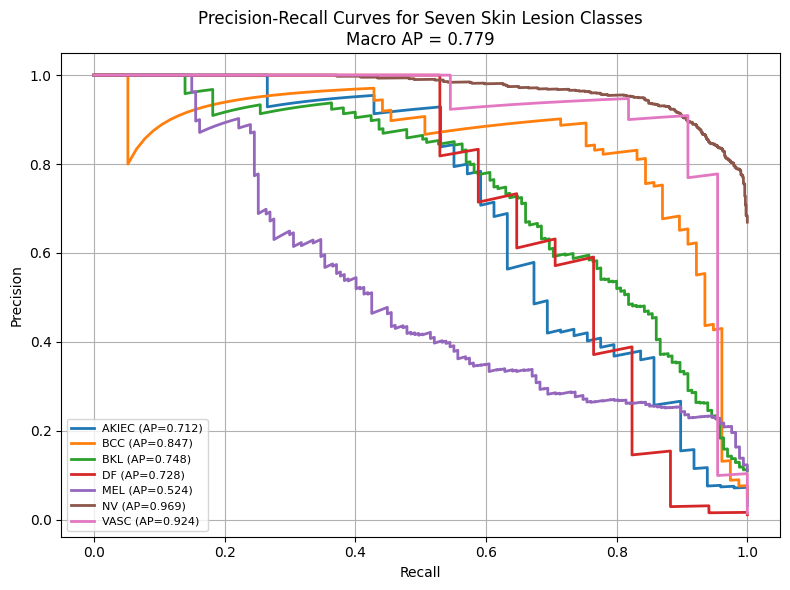

Average Precision per class:
AKIEC: 0.712
BCC: 0.847
BKL: 0.748
DF: 0.728
MEL: 0.524
NV: 0.969
VASC: 0.924

Macro AP: 0.779
Micro AP: 0.757


In [113]:
ap_scores, macro_ap, micro_ap = plot_pr_curve(
    model,
    test_loader,
    device,
    filename="pr_curve.png"
)